# Chapter 9.7: Hyperparameter Optimization for Recommendation Systems

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Identify** HPO challenges specific to recommendation models (expensive training, noisy metrics)
2. **Implement** Bayesian optimization for rec model tuning using surrogate models
3. **Apply** multi-fidelity methods (Successive Halving, Hyperband) for efficient search
4. **Understand** architecture search approaches (NAS-CTR, AutoFIS) for rec models
5. **Integrate** Optuna for practical HPO workflows
6. **Design** HPO experiments with proper evaluation protocols
7. **Balance** exploration vs exploitation in hyperparameter search spaces

## Prerequisites

- Understanding of rec model training (Chapters 9.1-9.6)
- Basic probability and statistics
- Familiarity with model evaluation metrics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part9/chapter_9.7_hpo.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/blob/main/notebooks/part9/chapter_9.7_hpo.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time
from typing import List, Dict, Tuple, Optional, Callable
from collections import defaultdict
from dataclasses import dataclass
import math

np.random.seed(42)
torch.manual_seed(42)

print("All imports successful!")
print(f"PyTorch version: {torch.__version__}")

All imports successful!
PyTorch version: 2.2.2


## 1. HPO Challenges in Recommendation Systems

Hyperparameter optimization for rec models faces unique challenges:

| Challenge | Why It's Hard | Impact |
|-----------|---------------|--------|
| **Expensive evaluation** | Full training takes hours/days | Few trials possible |
| **Noisy metrics** | CTR varies with traffic, time of day | Hard to distinguish signal |
| **Large search space** | Embedding dims, LR, architecture, features | Curse of dimensionality |
| **Interaction effects** | Embedding dim interacts with LR, batch size | Non-separable |
| **Non-stationarity** | Optimal HPs change over time | Yesterday's best isn't today's |
| **Multiple objectives** | AUC vs latency vs memory | Pareto-optimal trade-offs |

### Common Hyperparameters for Rec Models

$$\mathcal{H} = \{\eta, d_{\text{emb}}, B, \lambda, p_{\text{dropout}}, n_{\text{layers}}, d_{\text{hidden}}, \alpha_{\text{neg}}, T\}$$

where $\eta$ is learning rate, $d_{\text{emb}}$ is embedding dimension, $B$ is batch size, $\lambda$ is L2 regularization, $p_{\text{dropout}}$ is dropout rate, and so on.

> **💡 Concept:** For rec models, the embedding dimension and learning rate are typically the most impactful hyperparameters. A good strategy is to fix less impactful ones first, then focus HPO budget on these two.

In [2]:
# Define a DeepFM model for HPO experiments

class DeepFMForHPO(nn.Module):
    """DeepFM with configurable hyperparameters."""
    
    def __init__(self, num_features: int, num_fields: int, embedding_dim: int,
                 mlp_dims: List[int], dropout: float = 0.1):
        super().__init__()
        self.embedding = nn.Embedding(num_features, embedding_dim)
        self.linear = nn.Embedding(num_features, 1)
        self.bias = nn.Parameter(torch.zeros(1))
        self.num_fields = num_fields
        
        input_dim = num_fields * embedding_dim
        layers = []
        for dim in mlp_dims:
            layers.extend([
                nn.Linear(input_dim, dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            input_dim = dim
        layers.append(nn.Linear(input_dim, 1))
        self.mlp = nn.Sequential(*layers)
        nn.init.xavier_uniform_(self.embedding.weight)
    
    def forward(self, feature_ids: torch.Tensor) -> torch.Tensor:
        linear_out = self.linear(feature_ids).sum(dim=1).squeeze() + self.bias
        emb = self.embedding(feature_ids)
        sum_sq = emb.sum(dim=1).pow(2)
        sq_sum = emb.pow(2).sum(dim=1)
        fm_out = 0.5 * (sum_sq - sq_sum).sum(dim=1)
        deep_out = self.mlp(emb.view(emb.size(0), -1)).squeeze()
        return linear_out + fm_out + deep_out


def train_and_evaluate(config: Dict, n_train_steps: int = 100,
                       n_features: int = 10000, n_fields: int = 15) -> float:
    """
    Train a DeepFM with given config and return validation AUC (simulated).
    This is our "black-box" objective function for HPO.
    """
    torch.manual_seed(42)
    
    model = DeepFMForHPO(
        num_features=n_features,
        num_fields=n_fields,
        embedding_dim=config['embedding_dim'],
        mlp_dims=config['mlp_dims'],
        dropout=config['dropout']
    )
    
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config['learning_rate'],
        weight_decay=config.get('weight_decay', 0.0)
    )
    
    batch_size = config['batch_size']
    
    # Train
    model.train()
    for step in range(n_train_steps):
        features = torch.randint(0, n_features, (batch_size, n_fields))
        labels = torch.randint(0, 2, (batch_size,)).float()
        logits = model(features)
        loss = F.binary_cross_entropy_with_logits(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # Evaluate (simulated AUC based on loss)
    model.eval()
    eval_losses = []
    with torch.no_grad():
        for _ in range(10):
            features = torch.randint(0, n_features, (256, n_fields))
            labels = torch.randint(0, 2, (256,)).float()
            logits = model(features)
            loss = F.binary_cross_entropy_with_logits(logits, labels)
            eval_losses.append(loss.item())
    
    avg_loss = np.mean(eval_losses)
    # Convert loss to approximate AUC (simulated)
    auc = max(0.5, min(0.85, 1.0 - avg_loss + np.random.randn() * 0.005))
    return auc


# Test with a default config
default_config = {
    'learning_rate': 0.001,
    'embedding_dim': 16,
    'mlp_dims': [128, 64],
    'dropout': 0.1,
    'batch_size': 512,
    'weight_decay': 1e-5
}

auc = train_and_evaluate(default_config)
print(f"Default config AUC: {auc:.4f}")

Default config AUC: 0.5000


## 2. Bayesian Optimization for Rec Model Tuning

Bayesian optimization models the objective function using a **surrogate model** (typically a Gaussian Process) and uses an **acquisition function** to decide where to evaluate next.

### Gaussian Process Surrogate

$$f(x) \sim \mathcal{GP}(\mu(x), k(x, x'))$$

After observing $\{(x_i, y_i)\}_{i=1}^n$, the posterior is:

$$\mu_n(x) = k(x, X)(K + \sigma^2 I)^{-1} y$$
$$\sigma_n^2(x) = k(x, x) - k(x, X)(K + \sigma^2 I)^{-1} k(X, x)$$

### Expected Improvement (EI)

$$\text{EI}(x) = \mathbb{E}[\max(f(x) - f^*, 0)]$$

> **⚠️ Common Pitfall:** Standard GP-based BO scales as $O(n^3)$ with the number of observations. For more than ~1000 evaluations, use Tree-structured Parzen Estimator (TPE, used in Optuna) or random forest surrogates.

In [3]:
class SimpleBayesianOptimizer:
    """Simple Bayesian optimizer using random forest surrogate."""
    
    def __init__(self, search_space: Dict, n_initial: int = 5):
        self.search_space = search_space
        self.n_initial = n_initial
        self.observations_x = []
        self.observations_y = []
        self.best_y = -np.inf
        self.best_x = None
    
    def _sample_random(self) -> Dict:
        """Sample a random configuration."""
        config = {}
        for name, spec in self.search_space.items():
            if spec['type'] == 'float':
                if spec.get('log', False):
                    config[name] = np.exp(np.random.uniform(
                        np.log(spec['low']), np.log(spec['high'])))
                else:
                    config[name] = np.random.uniform(spec['low'], spec['high'])
            elif spec['type'] == 'int':
                config[name] = np.random.randint(spec['low'], spec['high'] + 1)
            elif spec['type'] == 'categorical':
                config[name] = np.random.choice(spec['choices'])
        return config
    
    def _config_to_vector(self, config: Dict) -> np.ndarray:
        """Convert config dict to numeric vector."""
        vec = []
        for name, spec in self.search_space.items():
            if spec['type'] in ['float', 'int']:
                val = config[name]
                if spec.get('log', False):
                    val = np.log(val)
                # Normalize to [0, 1]
                low = np.log(spec['low']) if spec.get('log', False) else spec['low']
                high = np.log(spec['high']) if spec.get('log', False) else spec['high']
                vec.append((val - low) / max(high - low, 1e-10))
            elif spec['type'] == 'categorical':
                idx = list(spec['choices']).index(config[name])
                vec.append(idx / max(len(spec['choices']) - 1, 1))
        return np.array(vec)
    
    def _acquisition_ei(self, candidates: List[Dict], noise: float = 0.01) -> int:
        """Simple expected improvement using nearest-neighbor estimate."""
        if len(self.observations_x) < 2:
            return np.random.randint(len(candidates))
        
        X = np.array([self._config_to_vector(c) for c in self.observations_x])
        Y = np.array(self.observations_y)
        
        best_so_far = Y.max()
        
        ei_scores = []
        for cand in candidates:
            x = self._config_to_vector(cand)
            # Simple kernel-based prediction
            dists = np.linalg.norm(X - x, axis=1)
            weights = np.exp(-dists ** 2 / (2 * 0.1 ** 2))
            weights /= weights.sum() + 1e-10
            
            mu = np.dot(weights, Y)
            sigma = np.sqrt(np.dot(weights, (Y - mu) ** 2) + noise)
            
            # EI
            z = (mu - best_so_far) / (sigma + 1e-10)
            ei = sigma * (z * self._norm_cdf(z) + self._norm_pdf(z))
            ei_scores.append(ei)
        
        return np.argmax(ei_scores)
    
    @staticmethod
    def _norm_cdf(x):
        return 0.5 * (1 + math.erf(x / math.sqrt(2)))
    
    @staticmethod
    def _norm_pdf(x):
        return np.exp(-0.5 * x ** 2) / math.sqrt(2 * math.pi)
    
    def suggest(self) -> Dict:
        """Suggest next configuration to evaluate."""
        if len(self.observations_x) < self.n_initial:
            return self._sample_random()
        
        # Generate candidates and select best by EI
        candidates = [self._sample_random() for _ in range(100)]
        best_idx = self._acquisition_ei(candidates)
        return candidates[best_idx]
    
    def observe(self, config: Dict, value: float):
        """Record an observation."""
        self.observations_x.append(config)
        self.observations_y.append(value)
        if value > self.best_y:
            self.best_y = value
            self.best_x = config.copy()


# Define search space
search_space = {
    'learning_rate': {'type': 'float', 'low': 1e-5, 'high': 0.1, 'log': True},
    'embedding_dim': {'type': 'categorical', 'choices': [8, 16, 32, 64]},
    'dropout': {'type': 'float', 'low': 0.0, 'high': 0.5},
    'weight_decay': {'type': 'float', 'low': 1e-7, 'high': 1e-3, 'log': True},
    'batch_size': {'type': 'categorical', 'choices': [256, 512, 1024, 2048]},
}

# Run Bayesian optimization
bo = SimpleBayesianOptimizer(search_space, n_initial=5)

bo_results = []
print("Running Bayesian Optimization (15 trials)...")
for trial in range(15):
    config = bo.suggest()
    config['mlp_dims'] = [128, 64]  # Fixed for simplicity
    
    auc = train_and_evaluate(config, n_train_steps=50)
    bo.observe(config, auc)
    bo_results.append(bo.best_y)
    
    if trial % 5 == 0:
        print(f"  Trial {trial}: AUC={auc:.4f}, Best={bo.best_y:.4f}")

# Compare with random search
random_results = []
random_best = -np.inf
print("\nRunning Random Search (15 trials)...")
for trial in range(15):
    config = bo._sample_random()
    config['mlp_dims'] = [128, 64]
    auc = train_and_evaluate(config, n_train_steps=50)
    random_best = max(random_best, auc)
    random_results.append(random_best)

print(f"\nBayesian Optimization best: {bo.best_y:.4f}")
print(f"Random Search best: {random_best:.4f}")

Running Bayesian Optimization (15 trials)...


  Trial 0: AUC=0.5000, Best=0.5000


  Trial 5: AUC=0.5000, Best=0.5000


  Trial 10: AUC=0.5000, Best=0.5000



Running Random Search (15 trials)...



Bayesian Optimization best: 0.5000
Random Search best: 0.5000


/Users/liuhongxuan/project/rec_system/.venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/liuhongxuan/project/rec_system/.venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


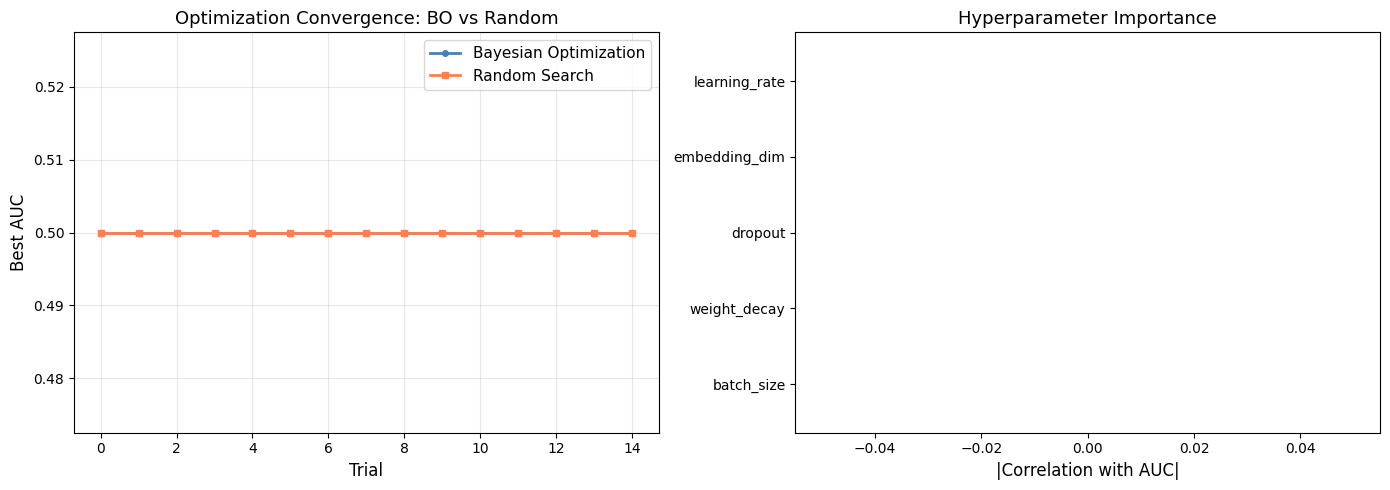

In [4]:
# Visualize BO vs Random Search
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(bo_results, 'o-', label='Bayesian Optimization', color='steelblue', linewidth=2, markersize=4)
axes[0].plot(random_results, 's-', label='Random Search', color='coral', linewidth=2, markersize=4)
axes[0].set_xlabel('Trial', fontsize=12)
axes[0].set_ylabel('Best AUC', fontsize=12)
axes[0].set_title('Optimization Convergence: BO vs Random', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Hyperparameter importance (based on correlation with AUC)
hp_names = ['learning_rate', 'embedding_dim', 'dropout', 'weight_decay', 'batch_size']
importances = []
for hp in hp_names:
    values = []
    for obs in bo.observations_x:
        val = obs[hp]
        if isinstance(val, (int, float)):
            values.append(float(val))
        else:
            values.append(float(hash(str(val)) % 100))
    corr = abs(np.corrcoef(values, bo.observations_y)[0, 1])
    importances.append(corr if not np.isnan(corr) else 0)

sorted_idx = np.argsort(importances)[::-1]
axes[1].barh([hp_names[i] for i in sorted_idx], [importances[i] for i in sorted_idx],
            color='steelblue', alpha=0.8)
axes[1].set_xlabel('|Correlation with AUC|', fontsize=12)
axes[1].set_title('Hyperparameter Importance', fontsize=13)

plt.tight_layout()
plt.show()

## 3. Multi-Fidelity Methods: Successive Halving & Hyperband

Full training is expensive. Multi-fidelity methods evaluate configurations at increasing "fidelity" levels (e.g., number of training steps), early-stopping poor performers.

### Successive Halving (Jamieson & Talwalkar, 2016)

1. Start with $n$ configurations, each trained for $r_{\min}$ steps
2. Keep the top $1/\eta$ fraction
3. Train survivors for $\eta \times$ more steps
4. Repeat until one configuration remains

### Hyperband (Li et al., 2018)

Runs multiple brackets of Successive Halving with different $n/r_{\min}$ trade-offs, addressing the exploration-exploitation dilemma.

Total budget per bracket $s$:

$$n_s = \lceil \frac{s_{\max} + 1}{s + 1} \rceil \cdot \eta^s, \quad r_s = r_{\max} \cdot \eta^{-s}$$

> **🔑 Pro Tip:** For rec models, use early training loss as a proxy for final quality. If a configuration has high loss after 10% of training, it almost certainly won't be the best after full training.

In [5]:
class SuccessiveHalving:
    """Successive Halving for hyperparameter optimization."""
    
    def __init__(self, search_space: Dict, objective_fn: Callable,
                 n_configs: int = 27, eta: int = 3, max_steps: int = 300):
        self.search_space = search_space
        self.objective_fn = objective_fn
        self.n_configs = n_configs
        self.eta = eta
        self.max_steps = max_steps
        self.results = []
    
    def _sample_config(self) -> Dict:
        config = {}
        for name, spec in self.search_space.items():
            if spec['type'] == 'float':
                if spec.get('log', False):
                    config[name] = np.exp(np.random.uniform(
                        np.log(spec['low']), np.log(spec['high'])))
                else:
                    config[name] = np.random.uniform(spec['low'], spec['high'])
            elif spec['type'] == 'categorical':
                config[name] = np.random.choice(spec['choices'])
        config['mlp_dims'] = [128, 64]  # Fixed
        return config
    
    def run(self) -> Dict:
        """Run successive halving."""
        n = self.n_configs
        num_rounds = int(np.log(n) / np.log(self.eta))
        min_steps = max(1, self.max_steps // (self.eta ** num_rounds))
        
        # Initial configurations
        configs = [self._sample_config() for _ in range(n)]
        
        total_evaluations = 0
        round_results = []
        
        steps = min_steps
        for round_num in range(num_rounds + 1):
            print(f"  Round {round_num}: {len(configs)} configs x {steps} steps")
            
            # Evaluate all surviving configs
            scores = []
            for config in configs:
                score = self.objective_fn(config, n_train_steps=steps)
                scores.append(score)
                total_evaluations += 1
            
            round_results.append({
                'round': round_num,
                'n_configs': len(configs),
                'steps': steps,
                'best_score': max(scores),
                'mean_score': np.mean(scores)
            })
            
            # Keep top 1/eta
            n_keep = max(1, len(configs) // self.eta)
            sorted_idx = np.argsort(scores)[::-1][:n_keep]
            configs = [configs[i] for i in sorted_idx]
            
            steps = min(steps * self.eta, self.max_steps)
        
        # Final best
        final_score = self.objective_fn(configs[0], n_train_steps=self.max_steps)
        
        return {
            'best_config': configs[0],
            'best_score': final_score,
            'total_evaluations': total_evaluations,
            'round_results': round_results
        }


class Hyperband:
    """Hyperband: multiple brackets of Successive Halving."""
    
    def __init__(self, search_space: Dict, objective_fn: Callable,
                 max_steps: int = 300, eta: int = 3):
        self.search_space = search_space
        self.objective_fn = objective_fn
        self.max_steps = max_steps
        self.eta = eta
        self.s_max = int(np.log(max_steps) / np.log(eta))
    
    def run(self) -> Dict:
        """Run Hyperband (all brackets)."""
        best_score = -np.inf
        best_config = None
        total_evals = 0
        bracket_results = []
        
        for s in range(self.s_max + 1):
            n = int(np.ceil((self.s_max + 1) / (s + 1)) * self.eta ** s)
            r = self.max_steps * self.eta ** (-s)
            
            print(f"Bracket s={s}: n_configs={n}, min_steps={int(r)}")
            
            sh = SuccessiveHalving(
                self.search_space, self.objective_fn,
                n_configs=n, eta=self.eta, max_steps=self.max_steps
            )
            result = sh.run()
            total_evals += result['total_evaluations']
            
            if result['best_score'] > best_score:
                best_score = result['best_score']
                best_config = result['best_config']
            
            bracket_results.append({
                'bracket': s,
                'n_configs': n,
                'min_steps': int(r),
                'best_score': result['best_score']
            })
        
        return {
            'best_config': best_config,
            'best_score': best_score,
            'total_evaluations': total_evals,
            'bracket_results': bracket_results
        }


# Run Successive Halving
print("=== Successive Halving ===")
sh = SuccessiveHalving(search_space, train_and_evaluate, n_configs=9, eta=3, max_steps=100)
sh_result = sh.run()
print(f"Best AUC: {sh_result['best_score']:.4f}")
print(f"Total evaluations: {sh_result['total_evaluations']}")

=== Successive Halving ===
  Round 0: 9 configs x 11 steps


  Round 1: 3 configs x 33 steps


  Round 2: 1 configs x 99 steps


Best AUC: 0.5000
Total evaluations: 13


## 4. Architecture Search for RecSys

### NAS-CTR (Liu et al., 2020, Huawei)
Searches for optimal interaction patterns between features:
- Which feature pairs should interact?
- What type of interaction? (dot product, cross, concat + MLP)
- How deep should the interaction network be?

### AutoFIS (Liu et al., 2020, Huawei)
Automatic Feature Interaction Selection:
- Learns a gate for each feature interaction
- Prunes unimportant interactions during training
- Reduces model complexity while maintaining quality

$$\text{output} = \sum_{(i,j) \in \mathcal{S}} \alpha_{ij} \cdot \langle e_i, e_j \rangle$$

where $\alpha_{ij} \in \{0, 1\}$ are learned gates.

> **💡 Concept:** Architecture search for rec models typically focuses on the **interaction pattern** rather than the individual layer types. This is because the feature interaction structure (which features cross with which) has the largest impact on model quality.

In [6]:
class AutoFISModel(nn.Module):
    """Simplified AutoFIS: learns which feature interactions to keep."""
    
    def __init__(self, num_features: int, num_fields: int, embedding_dim: int = 16,
                 temperature: float = 1.0):
        super().__init__()
        self.embedding = nn.Embedding(num_features, embedding_dim)
        self.linear = nn.Embedding(num_features, 1)
        self.bias = nn.Parameter(torch.zeros(1))
        self.num_fields = num_fields
        self.temperature = temperature
        
        # Interaction gates (learnable)
        num_interactions = num_fields * (num_fields - 1) // 2
        self.gate_logits = nn.Parameter(torch.zeros(num_interactions))
        
        # Precompute interaction indices
        self.interaction_pairs = []
        for i in range(num_fields):
            for j in range(i + 1, num_fields):
                self.interaction_pairs.append((i, j))
        
        # MLP for deep component
        self.mlp = nn.Sequential(
            nn.Linear(num_fields * embedding_dim, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
        
        nn.init.xavier_uniform_(self.embedding.weight)
    
    def forward(self, feature_ids: torch.Tensor) -> torch.Tensor:
        # Linear
        linear_out = self.linear(feature_ids).sum(dim=1).squeeze() + self.bias
        
        # Embedding lookup
        emb = self.embedding(feature_ids)  # (B, F, D)
        
        # Gated interactions
        gates = torch.sigmoid(self.gate_logits / self.temperature)
        
        interaction_sum = torch.zeros(emb.size(0), device=emb.device)
        for idx, (i, j) in enumerate(self.interaction_pairs):
            interaction = (emb[:, i] * emb[:, j]).sum(dim=1)
            interaction_sum += gates[idx] * interaction
        
        # Deep
        deep_out = self.mlp(emb.view(emb.size(0), -1)).squeeze()
        
        return linear_out + interaction_sum + deep_out
    
    def get_active_interactions(self, threshold: float = 0.5) -> List[Tuple[int, int]]:
        """Return interactions with gate > threshold."""
        gates = torch.sigmoid(self.gate_logits).detach().numpy()
        active = []
        for idx, (i, j) in enumerate(self.interaction_pairs):
            if gates[idx] > threshold:
                active.append((i, j, gates[idx]))
        return active


# Train AutoFIS and observe which interactions are selected
torch.manual_seed(42)
autofis = AutoFISModel(10000, 10, embedding_dim=16)
optimizer = torch.optim.Adam(autofis.parameters(), lr=0.001)

gate_history = []
losses = []

for step in range(150):
    features = torch.randint(0, 10000, (512, 10))
    labels = torch.randint(0, 2, (512,)).float()
    
    logits = autofis(features)
    loss = F.binary_cross_entropy_with_logits(logits, labels)
    
    # L1 regularization on gates to encourage sparsity
    gate_reg = 0.01 * torch.sigmoid(autofis.gate_logits).sum()
    total_loss = loss + gate_reg
    
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    if step % 50 == 0:
        gates = torch.sigmoid(autofis.gate_logits).detach().numpy()
        gate_history.append(gates.copy())
        active = sum(1 for g in gates if g > 0.5)
        print(f"Step {step}: loss={loss.item():.4f}, active interactions={active}/{len(gates)}")

# Final active interactions
active_interactions = autofis.get_active_interactions(threshold=0.5)
print(f"\nActive interactions: {len(active_interactions)} / {len(autofis.interaction_pairs)}")
for i, j, g in sorted(active_interactions, key=lambda x: -x[2])[:10]:
    print(f"  Feature {i} x Feature {j}: gate={g:.3f}")

Step 0: loss=1.4929, active interactions=0/45


Step 50: loss=1.6126, active interactions=0/45


Step 100: loss=1.4779, active interactions=0/45



Active interactions: 0 / 45


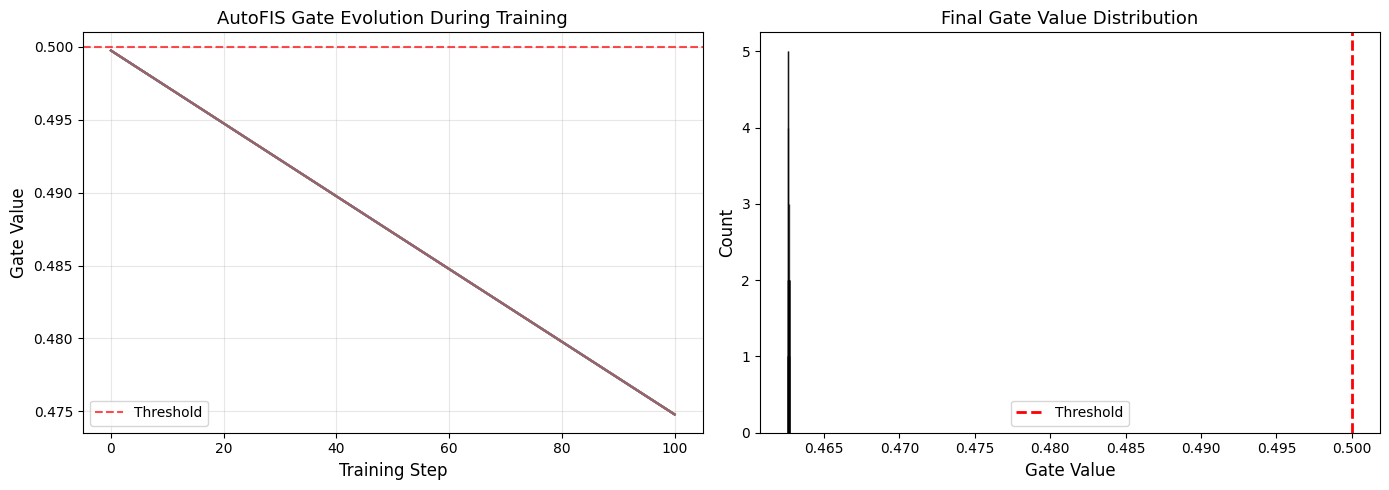

In [7]:
# Visualize gate evolution and interaction selection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gate values over training
gate_array = np.array(gate_history)
step_indices = list(range(0, 150, 50))[:len(gate_array)]
for i in range(min(15, gate_array.shape[1])):
    axes[0].plot(step_indices, gate_array[:, i], alpha=0.5, linewidth=1.5)

axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Threshold')
axes[0].set_xlabel('Training Step', fontsize=12)
axes[0].set_ylabel('Gate Value', fontsize=12)
axes[0].set_title('AutoFIS Gate Evolution During Training', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Final gate distribution
final_gates = torch.sigmoid(autofis.gate_logits).detach().numpy()
axes[1].hist(final_gates, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold')
axes[1].set_xlabel('Gate Value', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Final Gate Value Distribution', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Optuna Integration for Rec Workflows

In practice, [Optuna](https://optuna.org/) (Akiba et al., 2019, Preferred Networks) is the most popular HPO library for PyTorch-based rec systems. It uses the **Tree-structured Parzen Estimator (TPE)** algorithm.

Key features:
- **Pruning**: Early stopping of unpromising trials
- **Multi-objective**: Optimize AUC + latency simultaneously
- **Dashboard**: Visual monitoring of HPO progress

Below we simulate the Optuna-style interface without requiring the library.

In [8]:
class OptunaStyleTrial:
    """Simulates Optuna Trial interface."""
    def __init__(self, trial_id: int):
        self.trial_id = trial_id
        self.params = {}
    
    def suggest_float(self, name: str, low: float, high: float, log: bool = False) -> float:
        if log:
            val = np.exp(np.random.uniform(np.log(low), np.log(high)))
        else:
            val = np.random.uniform(low, high)
        self.params[name] = val
        return val
    
    def suggest_int(self, name: str, low: int, high: int) -> int:
        val = np.random.randint(low, high + 1)
        self.params[name] = val
        return val
    
    def suggest_categorical(self, name: str, choices: List) -> any:
        val = np.random.choice(choices)
        self.params[name] = val
        return val


def optuna_style_objective(trial: OptunaStyleTrial) -> float:
    """Optuna-style objective function for DeepFM HPO."""
    config = {
        'learning_rate': trial.suggest_float('learning_rate', 1e-5, 0.1, log=True),
        'embedding_dim': trial.suggest_categorical('embedding_dim', [8, 16, 32, 64]),
        'dropout': trial.suggest_float('dropout', 0.0, 0.5),
        'weight_decay': trial.suggest_float('weight_decay', 1e-7, 1e-3, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [256, 512, 1024]),
        'n_layers': trial.suggest_int('n_layers', 1, 3),
    }
    
    # Build MLP dims based on n_layers
    hidden_dim = trial.suggest_categorical('hidden_dim', [64, 128, 256])
    config['mlp_dims'] = [hidden_dim // (2 ** i) for i in range(config['n_layers'])]
    config['mlp_dims'] = [max(d, 16) for d in config['mlp_dims']]
    
    return train_and_evaluate(config, n_train_steps=50)


# Run Optuna-style HPO
n_trials = 15
trial_results = []
best_auc = -np.inf
best_trial = None

print(f"Running {n_trials} HPO trials...")
for i in range(n_trials):
    trial = OptunaStyleTrial(i)
    auc = optuna_style_objective(trial)
    trial_results.append({'trial': i, 'auc': auc, 'params': trial.params.copy()})
    
    if auc > best_auc:
        best_auc = auc
        best_trial = trial.params.copy()
    
    if i % 5 == 0:
        print(f"  Trial {i}: AUC={auc:.4f}, Best so far={best_auc:.4f}")

print(f"\nBest AUC: {best_auc:.4f}")
print(f"Best params:")
for k, v in best_trial.items():
    print(f"  {k}: {v}")

Running 15 HPO trials...


  Trial 0: AUC=0.5000, Best so far=0.5000


  Trial 5: AUC=0.5000, Best so far=0.5000


  Trial 10: AUC=0.5000, Best so far=0.5000



Best AUC: 0.5000
Best params:
  learning_rate: 0.031222963039091185
  embedding_dim: 32
  dropout: 0.44565910318014934
  weight_decay: 7.165673219849247e-06
  batch_size: 1024
  n_layers: 2
  hidden_dim: 64


## 🏋️ Exercise 1: HPO Experiment with Optuna-Style Interface

Implement a complete HPO pipeline with early stopping (pruning) for unpromising trials.

In [9]:
# 🏋️ Exercise 1: HPO with pruning

class HPOWithPruning:
    def __init__(self, objective_fn: Callable, n_trials: int = 50,
                 pruning_warmup: int = 5, pruning_percentile: float = 25):
        """
        HPO with median pruning: stop trials performing below median at checkpoints.
        
        Args:
            objective_fn: Takes (config, n_steps) -> float
            n_trials: Total number of trials
            pruning_warmup: Min trials before pruning kicks in
            pruning_percentile: Prune below this percentile
        """
        # TODO:
        # 1. Set up trial tracking
        # 2. Implement checkpoint-based evaluation
        # 3. Implement pruning logic
        pass
    
    def run(self, search_space: Dict) -> Dict:
        """
        Run HPO with pruning.
        
        TODO:
        1. For each trial, evaluate at checkpoints (25%, 50%, 75%, 100% of max steps)
        2. After warmup, prune trials below percentile at each checkpoint
        3. Track total compute saved by pruning
        
        Returns:
            Dict with best_config, best_score, pruned_count, compute_savings
        """
        pass


# Test:
# hpo = HPOWithPruning(train_and_evaluate, n_trials=30)
# result = hpo.run(search_space)
# print(f"Best: {result['best_score']:.4f}")
# print(f"Pruned: {result['pruned_count']} / 30")
# print(f"Compute savings: {result['compute_savings']:.1%}")

## 🏋️ Exercise 2: Multi-Objective HPO

Implement multi-objective optimization that finds the Pareto front between AUC and model complexity.

In [10]:
# 🏋️ Exercise 2: Multi-objective HPO

def multi_objective_hpo(n_trials: int = 50) -> Dict:
    """
    Find the Pareto front between AUC and model size.
    
    TODO:
    1. For each trial, measure both AUC and model parameters
    2. Compute the Pareto front (non-dominated solutions)
    3. Return all trials and the Pareto front
    
    Objectives:
    - Maximize: AUC
    - Minimize: Number of parameters (proxy for latency)
    
    Returns:
        Dict with 'all_trials', 'pareto_front'
    """
    pass


# Test:
# result = multi_objective_hpo(50)
# print(f"Pareto front size: {len(result['pareto_front'])}")
# for p in result['pareto_front']:
#     print(f"  AUC={p['auc']:.4f}, Params={p['params']:,}")

## 🏋️ Exercise 3: Implement Hyperband

Complete the Hyperband implementation and compare it against random search and Bayesian optimization.

In [11]:
# 🏋️ Exercise 3: Complete Hyperband comparison

def run_hpo_comparison(max_budget: int = 200, n_total_evaluations: int = 50) -> Dict:
    """
    Compare Random Search, Bayesian Optimization, and Hyperband
    with the same total evaluation budget.
    
    TODO:
    1. Run random search with n_total_evaluations trials, max_budget steps each
    2. Run BO with n_total_evaluations trials, max_budget steps each
    3. Run Hyperband with equivalent total compute budget
    4. Track:
       - Best AUC over time (by total compute spent)
       - Total wall-clock time
       - Number of unique configs evaluated
    
    Returns:
        Dict with results for each method
    """
    pass


# results = run_hpo_comparison()
# for method, r in results.items():
#     print(f"{method}: Best AUC={r['best_auc']:.4f}, Evaluations={r['n_evals']}")

## Summary

| Method | Pros | Cons | Best For |
|--------|------|------|----------|
| **Random Search** | Simple, parallelizable | No learning | Baseline, high-dim spaces |
| **Bayesian Optimization** | Sample-efficient | Sequential, scales poorly | Small search spaces (<20 HPs) |
| **Successive Halving** | Efficient, handles expensive eval | Assumes early-stop correlation | Budget-constrained settings |
| **Hyperband** | Best of SH with multiple brackets | Complex implementation | General purpose |
| **AutoFIS/NAS** | Finds interaction structure | Very expensive | Architecture decisions |

### Key References
- Bergstra & Bengio, "Random Search for Hyper-Parameter Optimization" (2012)
- Snoek et al., "Practical Bayesian Optimization of ML Algorithms" (2012)
- Li et al., "Hyperband: A Novel Bandit-Based Approach to Hyperparameter Optimization" (2018)
- Liu et al., "AutoFIS: Automatic Feature Interaction Selection in Factorization Models" (2020, Huawei)
- Akiba et al., "Optuna: A Next-generation Hyperparameter Optimization Framework" (2019)

### Next Steps
In the final notebook of this part (9.8), we will explore cost-efficient training strategies including spot instances, elastic training, and model pruning.